## 3DoF Entry MSL SCP

Imports

In [13]:
# Basic imports
import importlib
import numpy                as np
import matplotlib.pyplot    as plt
import pandas               as pd
import copy

# Trajopt imports --> pip install -e ~/ACL/trajopt
import trajopt; importlib.reload(trajopt)
import trajopt.core.modules.method.scp              as scp
import trajopt.core.Trajopt                         as prob
import trajopt.utils.config_loader                  as cfg
import trajopt.utils.tools                          as tools
import trajopt.analysis.default_analysis            as default_analysis
import trajopt.analysis.statistics                  as stats
import trajopt.core.modules.analysis.monte_carlo    as mc
import trajopt.core.modules.analysis.standalone     as standalone

from trajopt.analysis.trajplots import *

from trajopt.analysis.custom_functions_dan import max_q_nonjax, max_Q_nonjax, max_load_nonjax, terminal_cost
from trajopt.analysis.plots_for_scitech26 import *

np.random.seed(0)  # for reproducibility



In [14]:
example_name = "msl_entry_3dof"
method_name = "autotune"
nominal_config  = cfg.load_configs(example_name)

# create problem instance
trajopt_obj = prob.Problem(nominal_config)

# run SCP
trajopt_obj = scp.run_scp(trajopt_obj)

# store scenario data struct for plotting
scenario_data = standalone.run_standalone_analysis(trajopt_obj, method_name)

scales: 
d: 3396190.0000, t: 956.3609, m: 2900.0000, v: 3551.1593, a: 3.7132, f: 10768.2800, ang: 57.2958, angv: 0.0599, none: 1.0000
Initial guess time: 0.12665587500669062 seconds
Cost initial: 0.300915055819802
total number of parameters: 5941
--------------------------------------------------------------------------------------------------------------------------------------------------------
                                              ..:: msl: PTR with Virtual Buffer ::..
--------------------------------------------------------------------------------------------------------------------------------------------------------
  Iteration |  Propagation |   Solve   |    Parse   |  log(dz)  |      log(VB)    |   log(VB)   |  log(VB)    | Solve status |  Time of    |   Cost    
            |   time [ms]  | time [ms] |  time [ms] |           |  (path + NFZ)   |  (terminal) |  (dynamics) |              |  Flight [s] |           
----------------------------------------------------------

delete me

# Load data and preprocess... (compute loads...)

In [15]:
data = {'scenario1':scenario_data}
PLTS1 = SCVXPLOTS(data);
cases = {'scenarios':['scenario1'],'methods':['standard','autotune'],'runs':list(range(1000)),'iters':list(range(1000))[1:]}
preProcess(PLTS1,trajopt_obj,cases=cases);

KeyError: 'kQ'

# DASHBOARD

In [ ]:
%load_ext autoreload
%autoreload 2

versions = ['standalone','sa_iters'];
figpaths = ['figs/standalone/','figs/standalone/'];

displayfigs = True;
printfigs = True; 
transparentfigs = True; 

specs = {}

specs['standalone'] = {'methods':[method_name],'runs':[0],'itrs':[]};
specs['sa_iters'] = {'methods':[method_name],'runs':[0],'itrs':list(range(1000))[1:]};
specs['methodvar'] = {'methods':['standard','autotune'],'runs':[0]}; #,'itrs':list(range(1000))[1:]};
specs['mvmc'] = {'methods':['standard','autotune'],'runs':list(range(10))}; #,'itrs':list(range(1000))[1:]};
specs['montecarlo'] = {'methods':['standard'],'runs':list(range(1000))}; #'itrs':list(range(1000))[1:]};

######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- 
######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- 
######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- 

## default pens are set in the function plots_for_scitech26.py
## set new pens here. 
PENS = {};  
PENS['newpen'] = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,.0,1.],'lw':1,'ls':'--','msty':'' ,'msz':3};

## common pens to change
PENS['init'] = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,.0,1.],'lw':1,'ls':'--','msty':'' ,'msz':3};
PENS['itr']  = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,.2],'lw':1,'ls':'--','msty':'' ,'msz':3};
PENS['opt']  = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,1.],'lw':1,'ls':''  ,'msty':'o','msz':3};
PENS['prop'] = {'frgba':[.0,.0,.0,.1],'lrgba':[1.,.0,.0,1.],'lw':1,'ls':'-' ,'msty':'' ,'msz':3};
PENS['ref']  = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,.0,1.],'lw':1,'ls':'--','msty':'*','msz':3};
PENS['standard']  = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,1.],'lw':1,'ls':'-','msty':'o','msz':3};
PENS[method_name]  = {'frgba':[.0,.0,.0,.1],'lrgba':[1.,.0,1.,1.],'lw':1,'ls':'-','msty':'o','msz':3};

## weight pens (not currently in use)
# PENS['opt_weight']      = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
# PENS['opt_weight_0']    = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
# PENS['opt_weight_1']    = {'frgba':[.0,.0,.0,.1],'lrgba':[.2,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
# PENS['opt_weight_2']    = {'frgba':[.0,.0,.0,.1],'lrgba':[.4,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
# PENS['opt_weight_3']    = {'frgba':[.0,.0,.0,.1],'lrgba':[.6,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
# PENS['opt_weight_4']    = {'frgba':[.0,.0,.0,.1],'lrgba':[.8,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
# PENS['opt_weight_5']    = {'frgba':[.0,.0,.0,.1],'lrgba':[1.,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};

plotparams = {};
plotparams['trajopt_obj'] = trajopt_obj
plotparams['data'] = data;
plotparams['versions'] = versions;
plotparams['specs'] = specs;
plotparams['PENS'] = PENS;
plotparams['figpaths'] = figpaths;
plotparams['transparentfigs'] = transparentfigs;
plotparams['printfigs'] = printfigs;
plotparams['displayfigs'] = displayfigs;

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
ALL_PLOTS = False

if ALL_PLOTS:
    makePlotCtrls(PLTS1,ins=plotparams);
    makePlotCtrls2(PLTS1,ins=plotparams);
    makePlotTrajs(PLTS1,ins=plotparams);
    makePlotStates(PLTS1,ins=plotparams);
    makePlotLoads(PLTS1,ins=plotparams);
    makePlotWghts(PLTS1,ins=plotparams);
    makePlotWghts2(PLTS1,ins=plotparams);
    makePlotWghts3(PLTS1,ins=plotparams);
    makePlotConvs(PLTS1,ins=plotparams);
    makePlotConvs2(PLTS1,ins=plotparams);

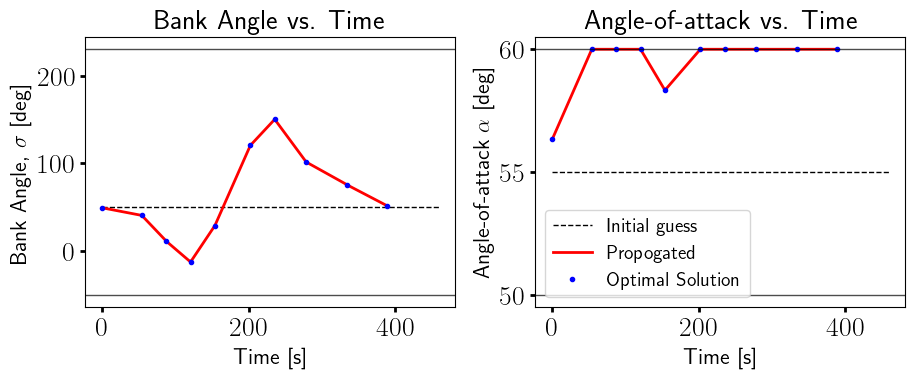

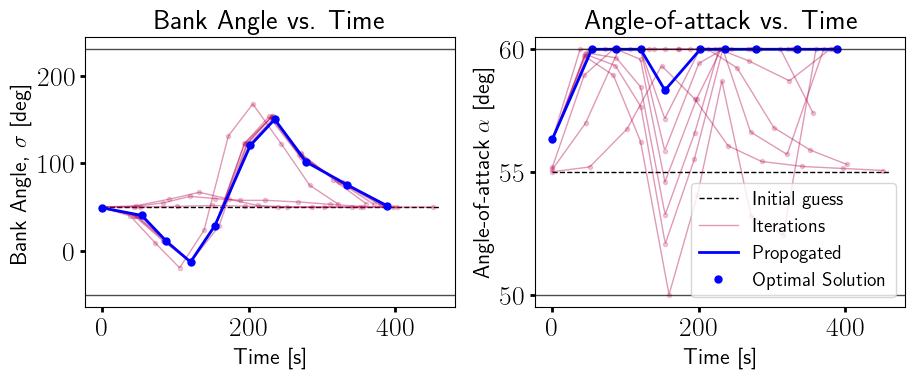

In [ ]:
params = {}

grid = {};
grid[0] = [0.05,0.05,0.37,0.9]; grid[1] = [0.50,0.05,0.37,0.9];
params['grid'] = grid;

params['uselegend'] = [1];

makePlotCtrls2(PLTS1,ins={**plotparams,**params});

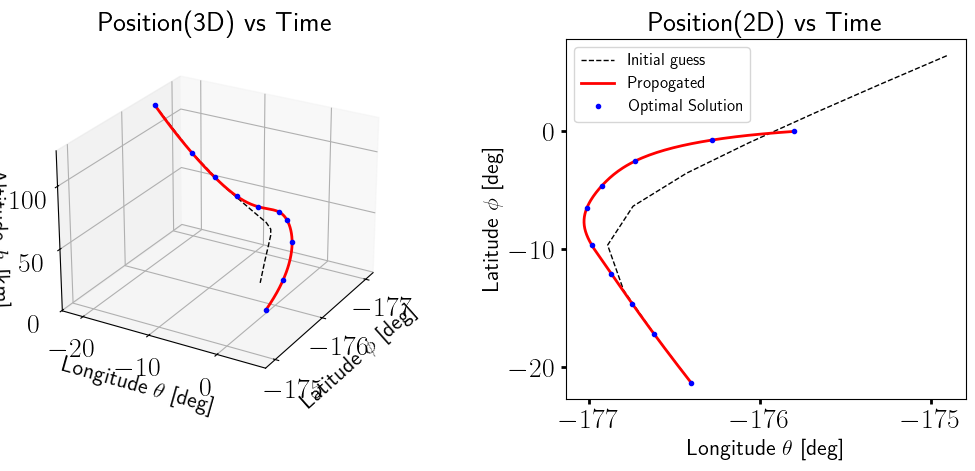

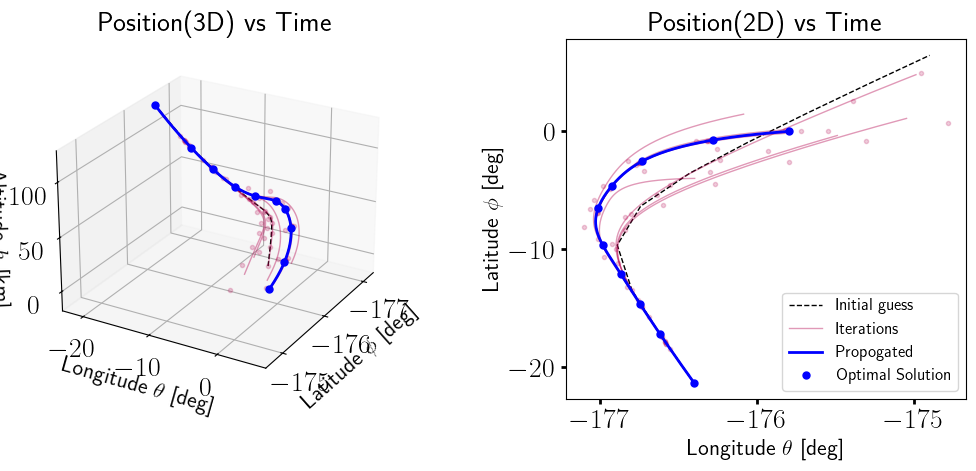

In [ ]:
params = {}
params['show_nfzs'] = False

grid = {};
grid[0] = [0.05,0.05,0.6,0.9]; grid[1] = [0.70,0.05,0.4,0.9];
params['grid'] = grid;

params['legendinfo'] = {'fontsize':12}

makePlotTrajs(PLTS1,ins={**plotparams,**params});

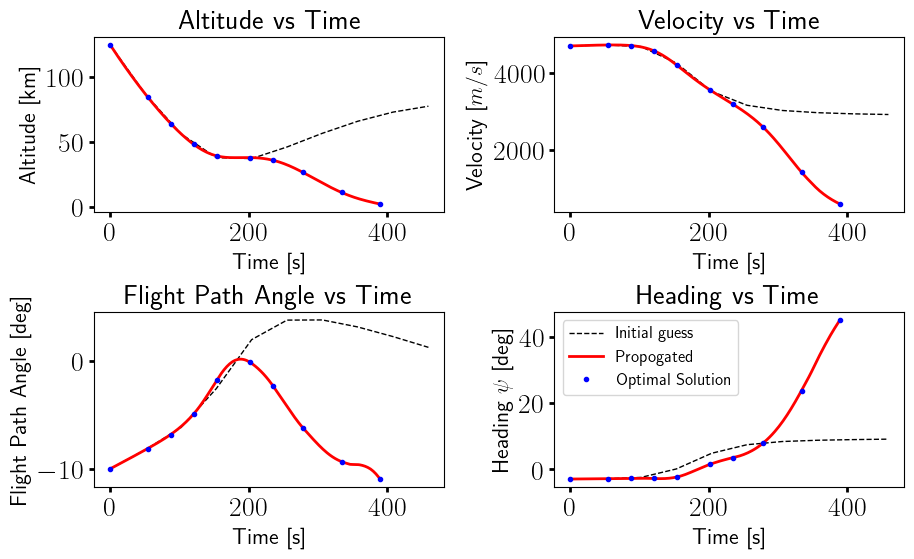

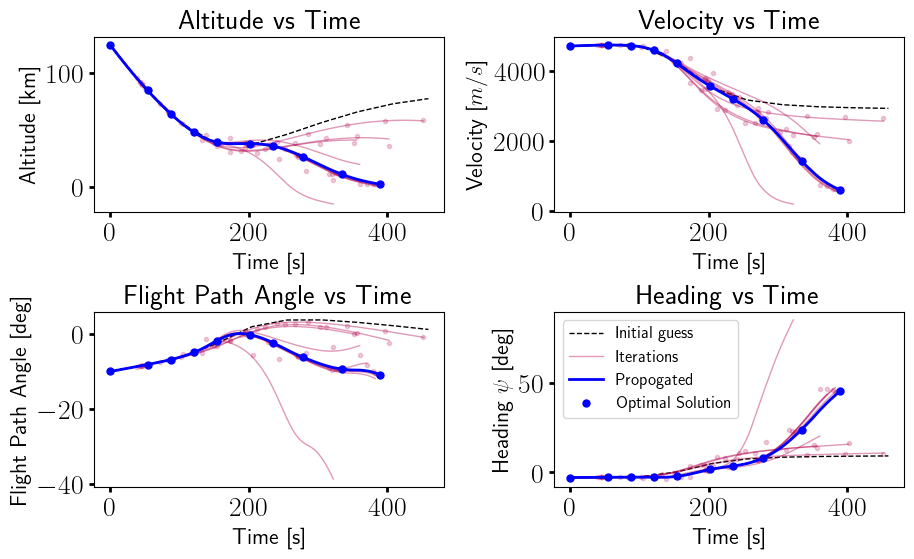

In [ ]:
makePlotStates(PLTS1,ins=plotparams);

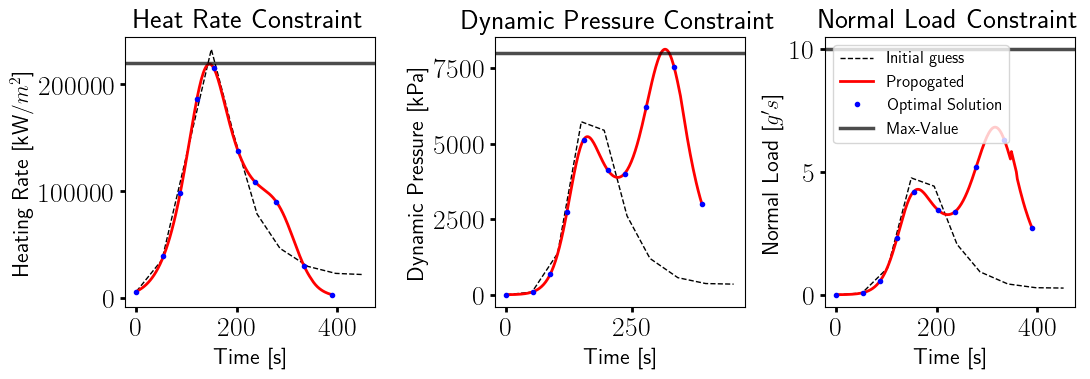

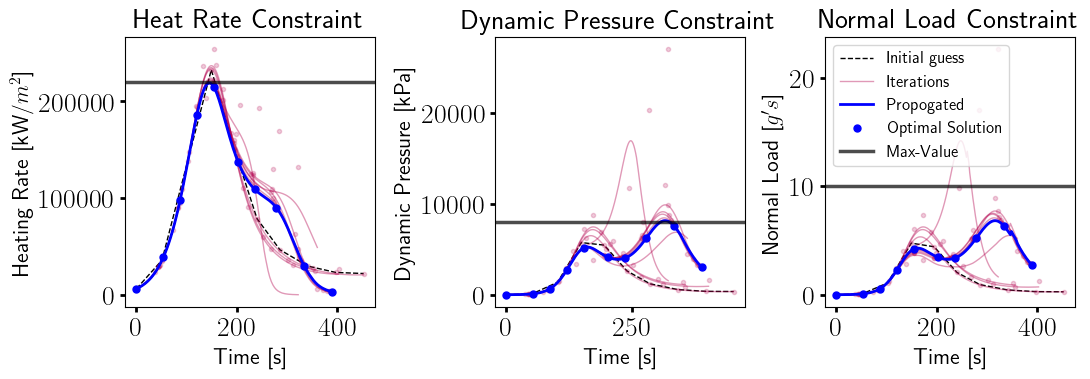

In [ ]:
makePlotLoads(PLTS1,ins=plotparams);

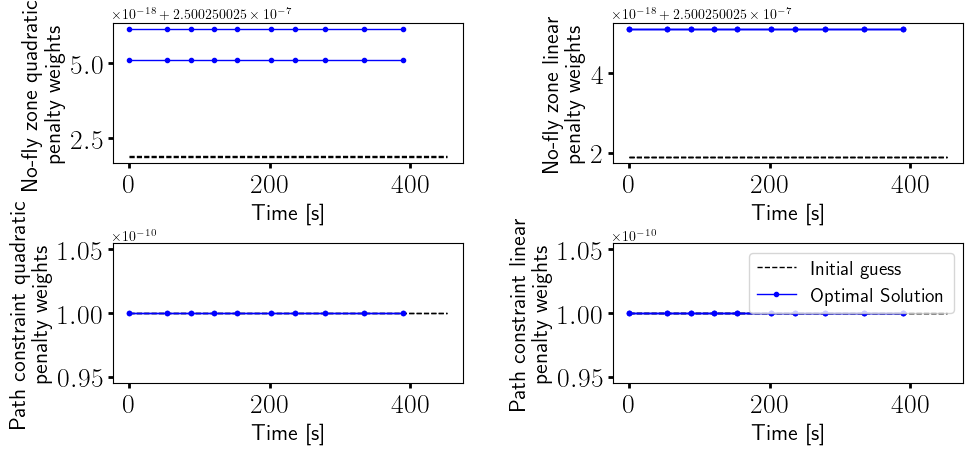

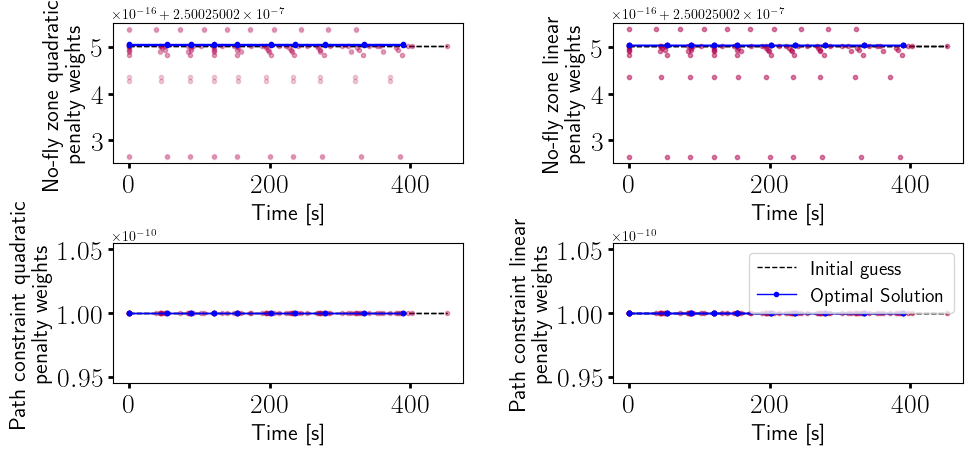

In [ ]:
makePlotWghts(PLTS1,ins=plotparams);

In [ ]:
#makePlotWghts2(PLTS1,ins=plotparams);

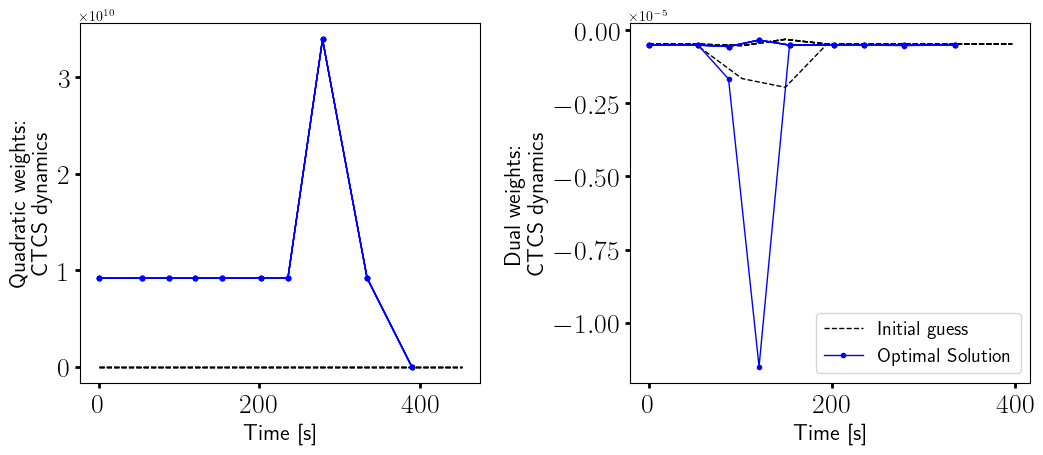

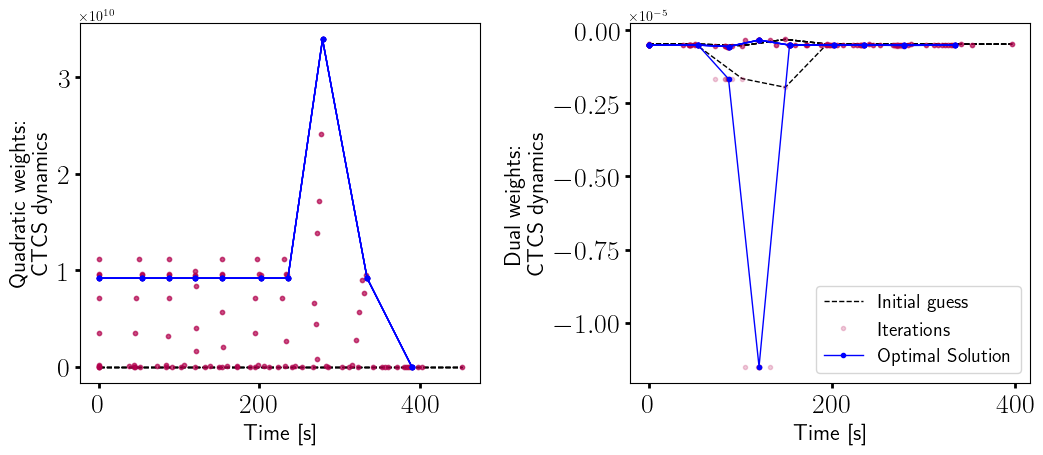

In [ ]:
makePlotWghts3(PLTS1,ins=plotparams);

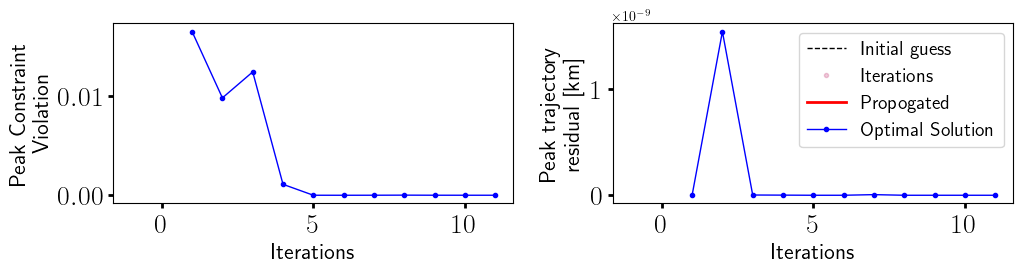

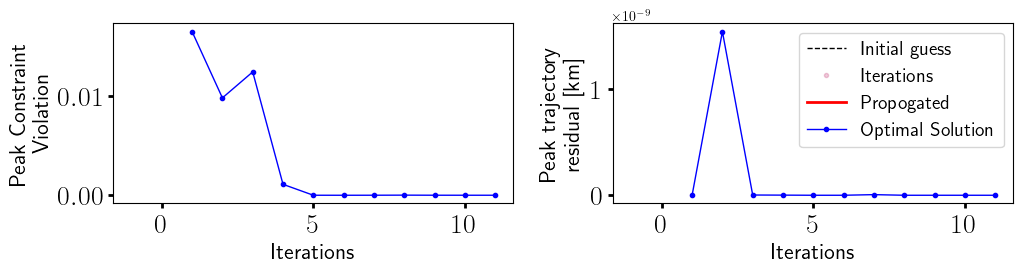

In [ ]:
makePlotConvs(PLTS1,ins=plotparams);

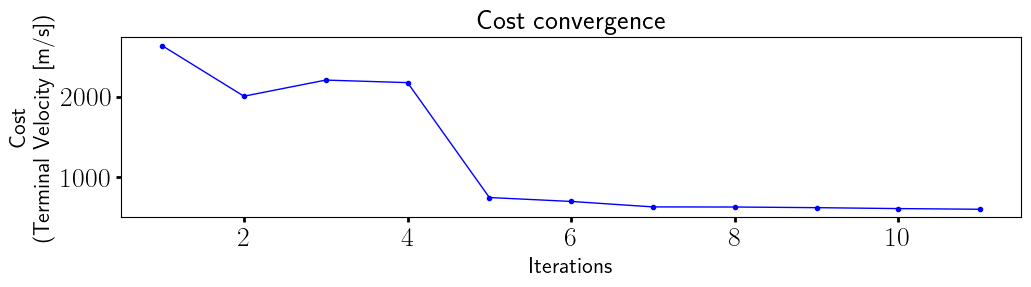

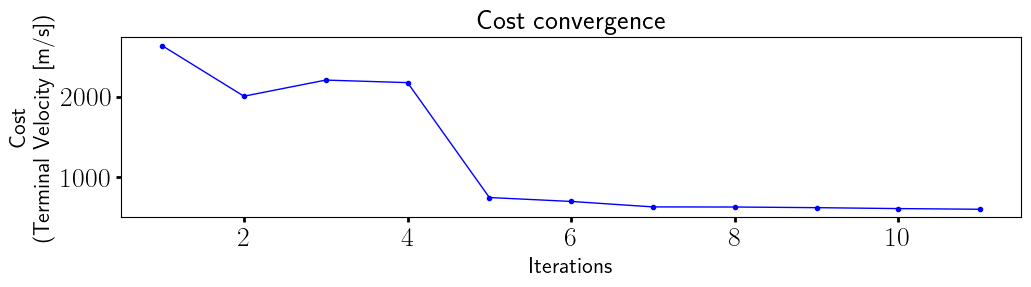

In [ ]:
makePlotConvs2(PLTS1,ins=plotparams);

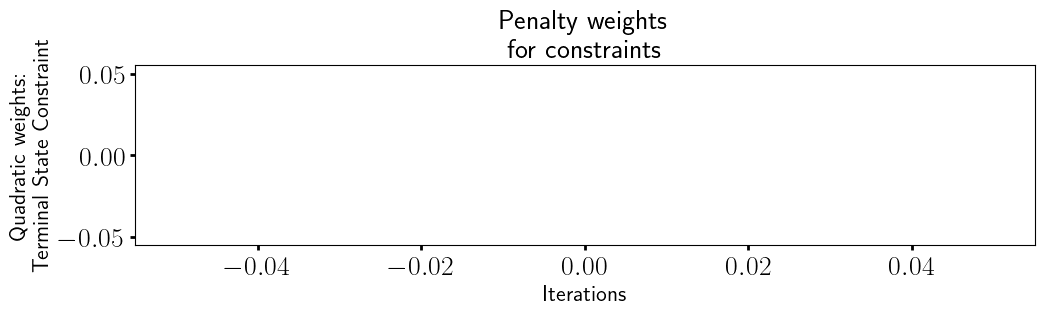

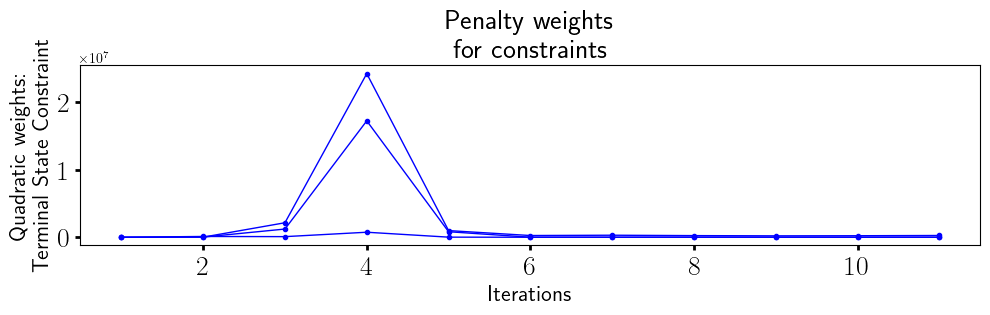

In [ ]:
makePlotConvs3(PLTS1,ins=plotparams);

# NOTES

In [ ]:
"""
params = {}
figsize = (10,5);
grid = {};
grid[0] = [0.05,0.6,0.4,0.35];  grid[1] = [0.55,0.6,0.4,0.35];
grid[2] = [0.05,0.05,0.4,0.35]; grid[3] = [0.55,0.05,0.4,0.35];
   
titles = {};
ylabels = {};
xlabels = {ind:'Time [s]' for ind in range(4)};
titles[0] = 'Attitude vs Time';
titles[1] = 'Velocity vs Time';
titles[2] = 'Flight Path Angle vs Time';
titles[3] = 'Heading vs Time';

ylabels[0] = 'Attitude [km]';
ylabels[1] = 'Velocity [$m/s$]';    
ylabels[2] = 'Flight Path Angle [deg]';
ylabels[3] = 'Heading $\psi$ [deg]';

params['titleinfo'] = {'fontsize':20,}
params['xlabelinfo'] = {'fontsize':20}
params['ylabelinfo'] = {'fontsize':20}
# params['ticksinfo'] = {'fontsize':20}
# params['legendinfo'] = {'fontsize':2}
params['uselegend'] = [0,1,3];

params['figsize'] = figsize; params['grid'] = grid;
params['titles'] = titles; params['xlabels'] = xlabels; params['ylabels'] = ylabels;
params['displayfigs'] = True;

makePlotStates(PLTS1,ins={**plotparams,**params});
"""

"\nparams = {}\nfigsize = (10,5);\ngrid = {};\ngrid[0] = [0.05,0.6,0.4,0.35];  grid[1] = [0.55,0.6,0.4,0.35];\ngrid[2] = [0.05,0.05,0.4,0.35]; grid[3] = [0.55,0.05,0.4,0.35];\n   \ntitles = {};\nylabels = {};\nxlabels = {ind:'Time [s]' for ind in range(4)};\ntitles[0] = 'Attitude vs Time';\ntitles[1] = 'Velocity vs Time';\ntitles[2] = 'Flight Path Angle vs Time';\ntitles[3] = 'Heading vs Time';\n\nylabels[0] = 'Attitude [km]';\nylabels[1] = 'Velocity [$m/s$]';    \nylabels[2] = 'Flight Path Angle [deg]';\nylabels[3] = 'Heading $\\psi$ [deg]';\n\nparams['titleinfo'] = {'fontsize':20,}\nparams['xlabelinfo'] = {'fontsize':20}\nparams['ylabelinfo'] = {'fontsize':20}\n# params['ticksinfo'] = {'fontsize':20}\n# params['legendinfo'] = {'fontsize':2}\nparams['uselegend'] = [0,1,3];\n\nparams['figsize'] = figsize; params['grid'] = grid;\nparams['titles'] = titles; params['xlabels'] = xlabels; params['ylabels'] = ylabels;\nparams['displayfigs'] = True;\n\nmakePlotStates(PLTS1,ins={**plotparams,*